# introduction to quantum audio
Article : [Quantum Representations of Sound: from
mechanical waves to quantum circuits](https://arxiv.org/pdf/2301.01595)


# Quantum Probability Amplitude Modulation: QPAM
For $N$ audio samples, with $n = \left\lceil log(N) \right\rceil$ qubits, the representation of the quantum state 
$$ |A_{QPAM}\rangle = \sum_{i=0}^{N-1}\alpha_i|i\rangle$$

Mapping the digital amplitudes audio to QPAM:\
audio amplitudes $a_i \neq$ probability amplitudes $\alpha_i$


Relation between $a_i$ and $\alpha_i$: 
- Step 1: add 1 to all amplitudes $a_i$
- Step 2: divide the amplitudes by 2.
- Step 3: divide again by the sum of al amplitudes
- Step 4: take the square root of the result

$$ \alpha_i = \frac{1}{\sqrt{g}}\sqrt{\frac{a_i+1}{2}},  \qquad g = \sum_k \frac{a_k+1}{2}$$



In [1]:
# module importation 
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram

In [2]:
# Functions
def samples2quantum(AudioAmplitudes):
    """
    conversion of audio samples to quantum probability amplitudes according to the previous equation
    Input : 
        - AudioAmplitudes(array)
    Output:
        - QuantumAmplitudes(array)
    """
    a = (AudioAmplitudes+1)/2
    g = sum(a)
    QuantumAmplitudes = np.sqrt(a)/np.sqrt(g)
    return QuantumAmplitudes

def getFullScaleMeasured(statistics, Nqubits):
    """
    fill the string measured with the null values measured
    Input : 
        - statistics(dict)
        - Nqubits(int)
    Output:
        - full_statistics(dict): statistics with the null values
    """
    full_statistics = {}
    for i in range(2**Nqubits):
        # Converts the integer i to binary and adds leading zeros (padding)
        bitstring = format(i, f'0{Nqubits}b')
        
        # If the flag is set, we take its value; otherwise, we set it to 0
        full_statistics[bitstring] = statistics.get(bitstring, 0)
    return full_statistics

def getProbabilityFromMeasurement(statistic):
    """
    Convert count to probabilities 
    Input : 
        - statistics(dict)
    Output:
        - meas_prob(array): probabilites of the input statistic
    """
    sorted_keys = sorted(full_statistics.keys())
    sorted_items = []
    for key in sorted_keys:
        sorted_items.append(full_statistics[key])
    meas_prob = np.array(sorted_items)/sum(sorted_items)
    return meas_prob

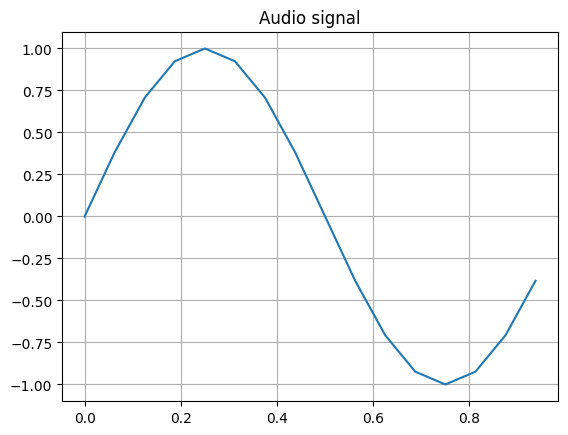

In [3]:
# Creation of an audio signal 

# audio samples
Nqubits = 4
temp = np.arange(0,2**Nqubits, 1)/2**Nqubits
amplitudes = np.sin(2*np.pi*temp)

plt.plot(temp, amplitudes)
plt.title("Audio signal")
plt.grid()

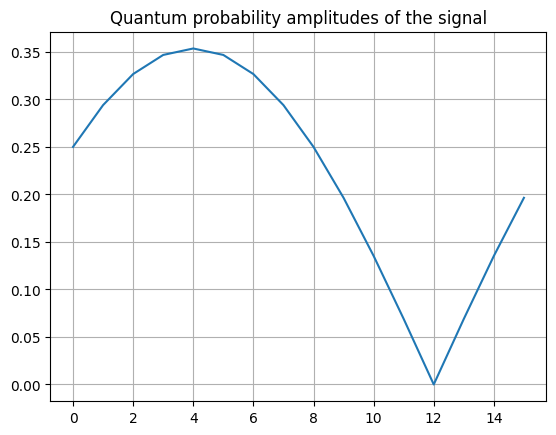

In [4]:
# conversion of signal amplitudes to quantum probability amplitudes
# convert audio to quantum state
prob = samples2quantum(amplitudes)

plt.plot(prob)
plt.title("Quantum probability amplitudes of the signal")
plt.grid()

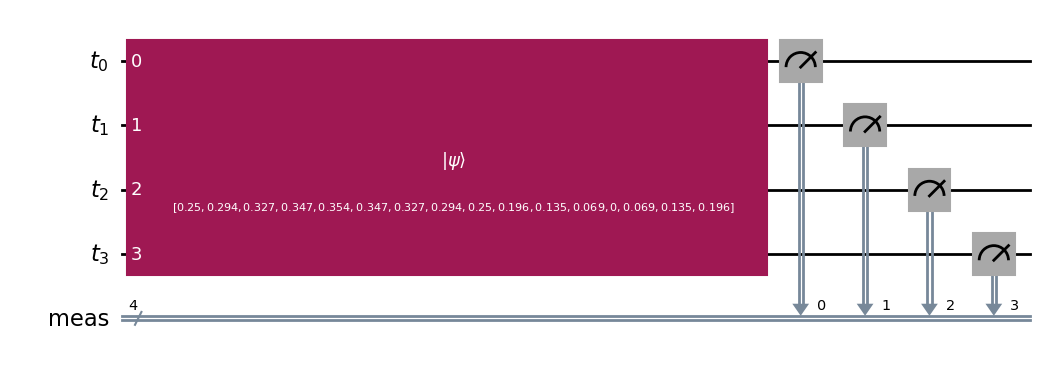

In [5]:
# Preparation of the circuit
t = QuantumRegister(Nqubits,"t")
meas = ClassicalRegister(Nqubits, "meas")
circuit = QuantumCircuit(t, meas)

# initialization of the quantum state
circuit.initialize(prob, range(Nqubits))  
circuit.measure(t, meas)
# Display the circuit 
display(circuit.draw(output="mpl"))

### Estimation of the audio samples amplitudes
the relation between the probabilites and the audio amplitudes samples are:
$$ a_i = 2g|\alpha_i|^2-1 $$ 

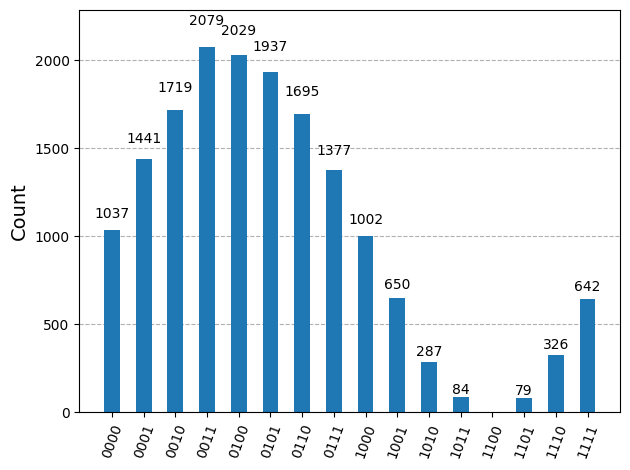

In [6]:
# The circuit can be run many times to evaluate the output measures and realise an histogram
nombre_de_shots = 2**14
result = AerSimulator().run(circuit, shots = nombre_de_shots).result()
statistics = result.get_counts()

# fill the empty values
full_statistics = getFullScaleMeasured(statistics, Nqubits)
display(plot_histogram(full_statistics))

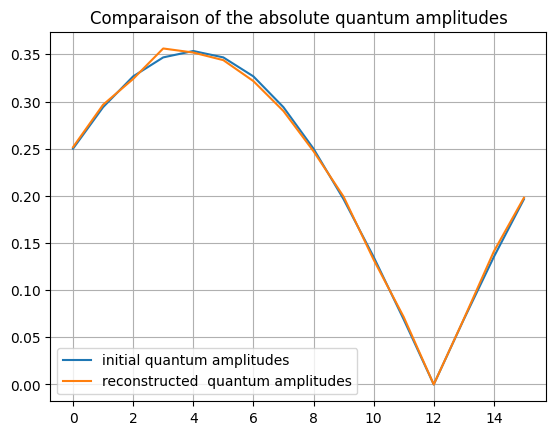

In [7]:
meas_prob = getProbabilityFromMeasurement(full_statistics)

# representation of the reconstruct signal 
plt.plot(prob, label="initial quantum amplitudes")
plt.plot(np.sqrt(meas_prob), label="reconstructed  quantum amplitudes")
plt.title("Comparaison of the absolute quantum amplitudes")
plt.legend()
plt.grid()

### Reconstruction of the signal 

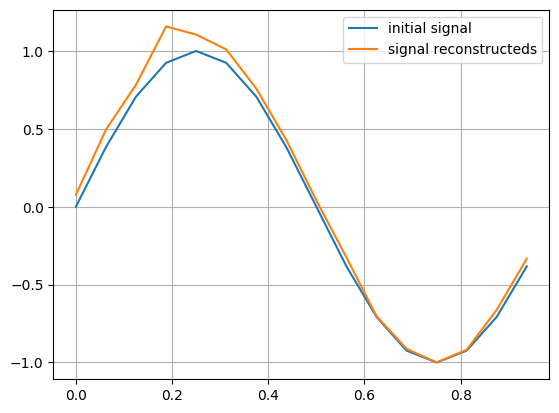

In [8]:
#reconstruction of the audio signal 
g_estimation = np.sum((meas_prob+1)/2)

estimate_amplitudes = 2*g_estimation*meas_prob-1
plt.plot(temp, amplitudes, label="initial signal ")
plt.plot(temp, estimate_amplitudes, label="signal reconstructeds")
plt.grid()
plt.legend()